In [1]:
import tensorflow as tf
from pathlib import Path
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.models import load_model
import numpy as np
from sklearn.metrics import classification_report

## EcoSort-Search — Modèle de classification des déchets

Entraînement d'un classifieur d'images pour 6 catégories de déchets
(cardboard, glass, metal, paper, plastic, trash) via Transfer Learning
sur EfficientNetB3, en préparation de l'intégration Flask/Docker.

In [2]:
# Configuration : chemins et hyperparamètres du projet
BASE_DIR = Path.cwd().parent
DATA_DIR = BASE_DIR / "data"
MODELS_DIR = BASE_DIR / "models"
MODELS_DIR.mkdir(exist_ok=True)

BATCH_SIZE = 32
IMG_HEIGHT = 300
IMG_WIDTH = 300
SEED = 42
NUM_CLASSES = 6

### Justification des choix techniques

**EfficientNetB3** offre un bon compromis entre précision et poids
computationnel grâce au compound scaling (profondeur, largeur,
résolution ajustées ensemble). On a fait ça pour limiter la taille du conteneur
Docker final tout en conservant une précision élevée sur des images
300x300.

**6 classes** correspondent aux catégories standard du tri sélectif
(cardboard, glass, metal, paper, plastic, trash), alignées avec le
pipeline de scraping Jumia et les besoins du tri automatisé.

In [4]:
# Vérification : intégrité du dossier de données
if DATA_DIR.exists():
    classes = [d.name for d in DATA_DIR.iterdir() if d.is_dir()]
    print(f"Dossier trouvé : {DATA_DIR}")
    print(f"Classes détectées : {classes}")
    for categorie in classes:
        nb_images = len(list((DATA_DIR / categorie).iterdir()))
        print(f"Catégorie {categorie} : {nb_images} images")
else:
    print(f"Erreur : dossier introuvable à {DATA_DIR}")

Dossier trouvé : c:\Users\user\Documents\EcoSort-Search\data
Classes détectées : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']
Catégorie cardboard : 403 images
Catégorie glass : 501 images
Catégorie metal : 410 images
Catégorie paper : 594 images
Catégorie plastic : 482 images
Catégorie trash : 137 images


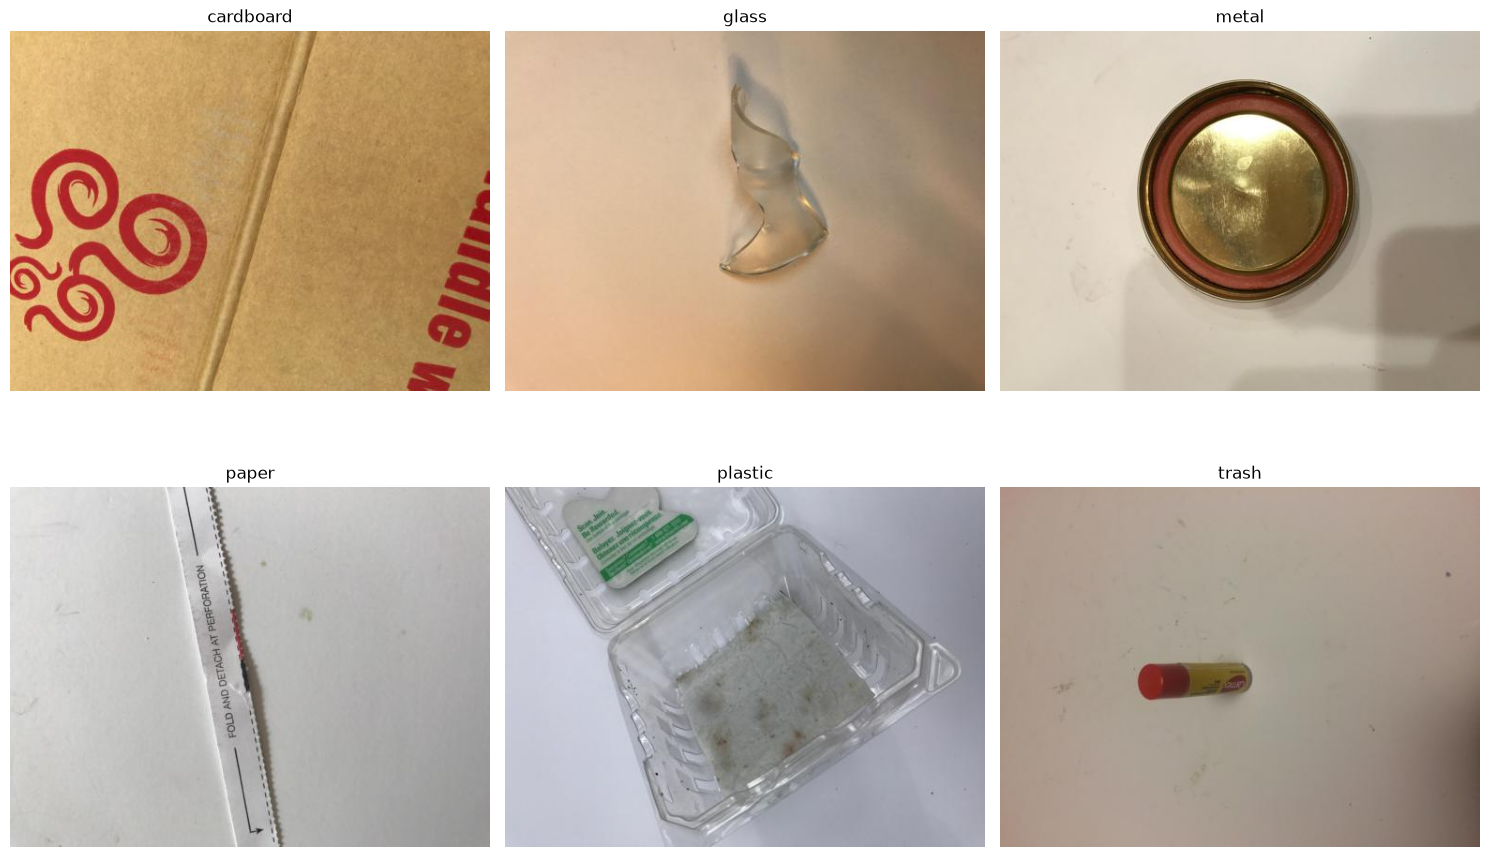

In [5]:
# Visualisation d'un échantillon aléatoire par classe
import cv2
import matplotlib.pyplot as plt
import random

plt.figure(figsize=(15, 10))

for i, categorie in enumerate(classes):
    chemin_classe = DATA_DIR / categorie
    images = list(chemin_classe.iterdir())
    image_choisie = random.choice(images)

    img = cv2.imread(str(image_choisie))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(2, 3, i + 1)
    plt.imshow(img_rgb)
    plt.title(categorie)
    plt.axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Chargement : ensembles d'entraînement et de validation
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# Extraction des noms de classes avant optimisation du pipeline
class_names = train_ds.class_names
print(f"Classes chargées : {class_names}")

# Optimisation des performances du pipeline
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 2527 files belonging to 6 classes.
Using 2022 files for training.
Found 2527 files belonging to 6 classes.
Using 505 files for validation.
Classes chargées : ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [7]:
# Architecture : EfficientNetB3 en Transfer Learning
base_model = EfficientNetB3(
    input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 300, 300, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         9,222 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,792,757 (41.17 MB)

 Trainable params: 9,222 (36.02 KB)

 Non-trainable params: 10,783,535 (41.14 MB)

In [8]:
# Sauvegarde automatique du meilleur modèle
checkpoint_callback = ModelCheckpoint(
    filepath=str(MODELS_DIR / 'modele_eco_sort_best.keras'),
    save_best_only=True,
    monitor='val_accuracy',
    verbose=1
)

# Arrêt anticipé si la perte de validation ne progresse plus
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Réduction du taux d'apprentissage en cas de stagnation
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[checkpoint_callback, early_stopping, reduce_lr]
)

Epoch 1/20


c:\Users\user\Documents\EcoSort-Search\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.6805 - loss: 0.9743
Epoch 1: val_accuracy improved from None to 0.81188, saving model to c:\Users\user\Documents\EcoSort-Search\models\modele_eco_sort_best.keras

Epoch 1: finished saving model to c:\Users\user\Documents\EcoSort-Search\models\modele_eco_sort_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 689s 10s/step - accuracy: 0.6805 - loss: 0.9743 - val_accuracy: 0.8119 - val_loss: 0.6108 - learning_rate: 0.0010
Epoch 2/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - accuracy: 0.8541 - loss: 0.4991
Epoch 2: val_accuracy improved from 0.81188 to 0.86337, saving model to c:\Users\user\Documents\EcoSort-Search\models\modele_eco_sort_best.keras

Epoch 2: finished saving model to c:\Users\user\Documents\EcoSort-Search\models\modele_eco_sort_best.keras
64/64 ━━━━━━━━━━━━━━━━━━━━ 644s 10s/step - accuracy: 0.8541 - loss: 0.4991 - val_accuracy: 0.8634 - val_loss: 0.4632 - learning_rate: 0.0010
Epoch 3/20
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy:

### Phase 2 : Fine-tuning

Dégel des dernières couches d'EfficientNetB3 pour affiner la
reconnaissance spécifique aux textures de déchets (verre, carton,
métal), avec un taux d'apprentissage très réduit pour éviter
d'effacer les connaissances déjà acquises sur ImageNet.

In [9]:
# Dégel des 20 dernières couches d'EfficientNetB3 pour le fine-tuning
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

# Réduction du taux d'apprentissage : indispensable en fine-tuning
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 300, 300, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 300, 300, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb3 (Functional)     │ (None, 10, 10, 1536)   │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │         9,222 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,792,757 (41.17 MB)

 Trainable params: 3,382,374 (12.90 MB)

 Non-trainable params: 7,410,383 (28.27 MB)

In [10]:
# Entraînement de la phase de fine-tuning
history_fine_tuning = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[checkpoint_callback, early_stopping, reduce_lr]
)

Epoch 1/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9362 - loss: 0.2155
Epoch 1: val_accuracy did not improve from 0.90297
64/64 ━━━━━━━━━━━━━━━━━━━━ 508s 7s/step - accuracy: 0.9362 - loss: 0.2155 - val_accuracy: 0.8990 - val_loss: 0.3095 - learning_rate: 1.0000e-05
Epoch 2/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9471 - loss: 0.1964
Epoch 2: val_accuracy did not improve from 0.90297
64/64 ━━━━━━━━━━━━━━━━━━━━ 442s 7s/step - accuracy: 0.9471 - loss: 0.1964 - val_accuracy: 0.8990 - val_loss: 0.3139 - learning_rate: 1.0000e-05
Epoch 3/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9411 - loss: 0.1911
Epoch 3: val_accuracy did not improve from 0.90297

Epoch 3: ReduceLROnPlateau reducing learning rate to 1.9999999494757505e-06.
64/64 ━━━━━━━━━━━━━━━━━━━━ 444s 7s/step - accuracy: 0.9411 - loss: 0.1911 - val_accuracy: 0.9010 - val_loss: 0.3146 - learning_rate: 1.0000e-05
Epoch 4/10
64/64 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.9530 - loss: 0.1724
Epoch

In [11]:
# Évaluation : rapport de classification sur le jeu de validation
y_pred = model.predict(val_ds)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.concatenate([y for x, y in val_ds], axis=0)
y_true_classes = np.argmax(y_true, axis=1)

print(classification_report(y_true_classes, y_pred_classes, target_names=class_names))

16/16 ━━━━━━━━━━━━━━━━━━━━ 92s 5s/step
              precision    recall  f1-score   support

   cardboard       0.94      0.94      0.94        69
       glass       0.92      0.87      0.89       102
       metal       0.84      0.98      0.91        88
       paper       0.95      0.93      0.94       123
     plastic       0.87      0.87      0.87        89
       trash       0.82      0.68      0.74        34

    accuracy                           0.90       505
   macro avg       0.89      0.88      0.88       505
weighted avg       0.90      0.90      0.90       505



In [13]:
from tensorflow.keras.models import load_model

model = load_model(MODELS_DIR / 'modele_eco_sort_best.keras')
model.save(MODELS_DIR / 'modele_eco_sort_finetuned.h5')
print("Modèle exporté (meilleure version : 90.3% accuracy validation)")

Modèle exporté (meilleure version : 90.3% accuracy validation)
